In [1]:
%run -i ../python_scripts/nb_setup.py

GPU Available: True
GPU Name: NVIDIA GeForce RTX 4060


In [298]:
def diff(p):
    b, n1, r1, n2, r2 = p
    n1 = max(1, int(round(n1)))
    n2 = max(1, int(round(n2)))
    e1 = int(n1 * r1)
    e2 = int(n2 * r2)
    return binom_sum(b=b, e=e1, n=n1) - binom_sum(b=b, e=e2, n=n2)

In [299]:
def safe_diff(p):
    try:
        val = diff(p)
        if not np.isfinite(val):
            return 1e20
        return val
    except Exception:
        return 1e20

In [118]:
from scipy.optimize import minimize

In [308]:
bounds = [(0, 1), (1, 100000), (0, 1), (1, 100000), (0, 1)]

x0 = [
    (
        rd.randint(lo, hi)
        if isinstance(lo, int) and isinstance(hi, int)
        else rd.uniform(lo, hi)
    )
    for lo, hi in bounds
]

constraints = [
    {"type": "ineq", "fun": lambda p: p[1] - p[3] - 1},
    {"type": "ineq", "fun": lambda p: p[2] - p[4]},
]

result = minimize(safe_diff, x0, bounds=bounds, constraints=constraints, method="SLSQP")
print("Minimum value:", result.fun)
print("Optimal parameters:", result.x)

Minimum value: 0
Optimal parameters: [1.0000e+00 9.8051e+04 1.0000e+00 7.2479e+04 1.0000e+00]


In [ ]:
solutions = []

N_RUNS = 500  # or however many you want
TOL = 1e-8  # tolerance for "minimum = 0"

for _ in tqdm(range(N_RUNS)):
    x0 = [
        (
            rd.randint(lo, hi)
            if isinstance(lo, int) and isinstance(hi, int)
            else rd.uniform(lo, hi)
        )
        for lo, hi in bounds
    ]

    result = minimize(
        safe_diff, x0, bounds=bounds, constraints=constraints, method="SLSQP"
    )

    if result.success and abs(result.fun) < TOL:
        solutions.append(result.x)

solutions = np.array(solutions)

100%|██████████| 500/500 [05:55<00:00,  1.41it/s]

Collected 90 zero-minimum solutions


In [311]:
corr = np.corrcoef(solutions, rowvar=False)

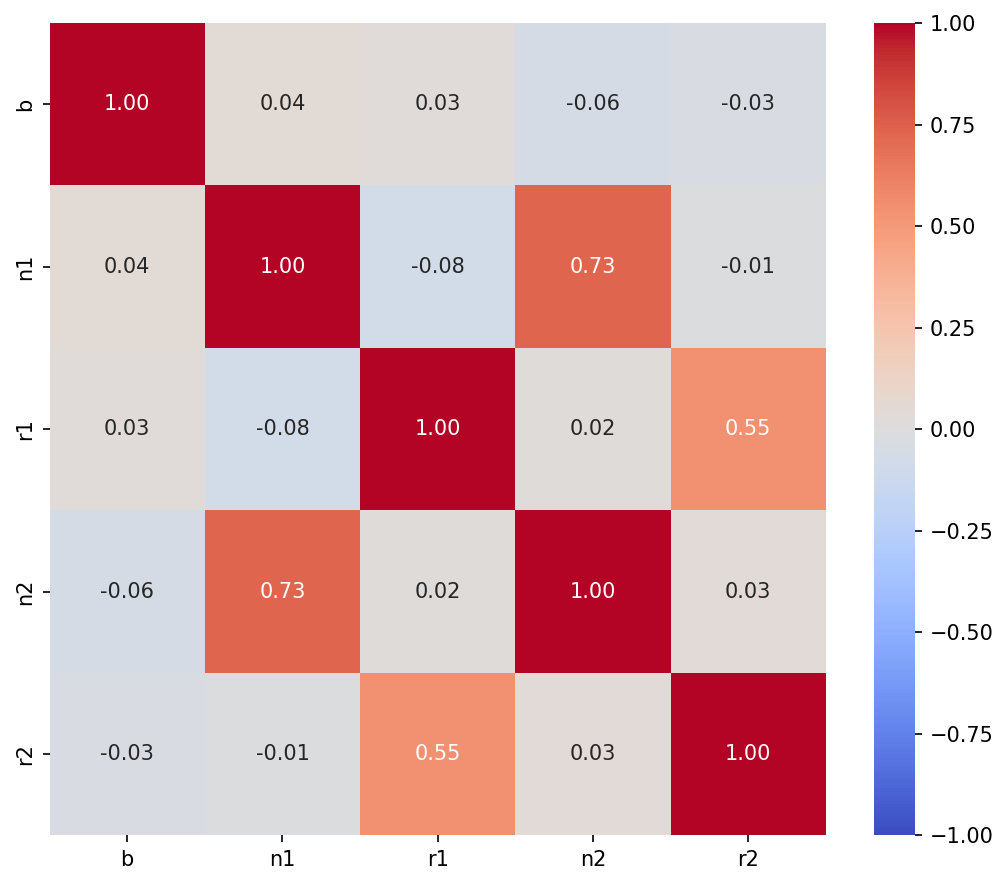

In [315]:
import seaborn as sns
import matplotlib.pyplot as plt

param_names = ["b", "n1", "r1", "n2", "r2"]

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr,
    xticklabels=param_names,
    yticklabels=param_names,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

df = pd.DataFrame(solutions, columns=param_names)
sns.pairplot(df, corner=True)
plt.show()

In [244]:
bs, diffs, v = [], [], []

for _ in tqdm(range(1000)):

    b = rd.uniform(0, 0.99)
    n1 = rd.randint(2, 100000)
    n2 = rd.randint(1, n1 - 1)
    r1 = rd.uniform(0, 1)
    r2 = rd.uniform(0, r1)

    e1 = int(n1 * r1)
    e2 = int(n2 * r2)
    diff = binom_sum(b=b, e=e1, n=n1) - binom_sum(b=b, e=e2, n=n2)

    bs.append(b)
    diffs.append(diff)
    v.append((1 - r2) * n1 / ((1 - r1) * n2))

100%|██████████| 1000/1000 [04:08<00:00,  4.02it/s]


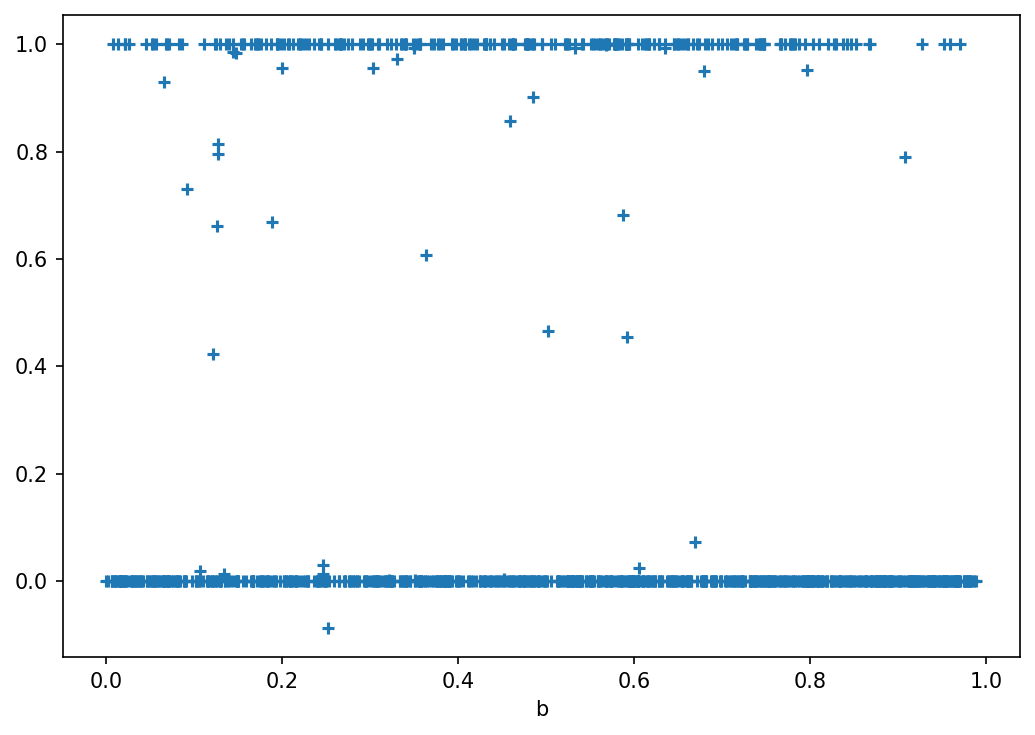

In [245]:
plt.figure(figsize=(7, 5))
sc = plt.scatter(bs, diffs, marker="+")  # , c=v, cmap="coolwarm", alpha=0.7)
# plt.colorbar(sc, label=r"$n_1 - n_2$")
plt.xlabel("b")
plt.tight_layout()
plt.show()